# Spam Detection Project
- Goal: Build a model to classify SMS/email messages as spam or ham.
- Dataset: spam_dataset.csv
- Model: Multinomial Naive Bayes (chosen for text data compatibility).
- App: Streamlit app for real-time predictions.
- Challenges: Initial model classified all messages as spam; fixed by switching to MultinomialNB.

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('spam_dataset.csv')

In [3]:
df.sample(10)

,Unnamed: 0,label,text,label_num
3036,4156,spam,Subject: pervers\r\nfrauen in lack und leder !...,1
2829,3740,spam,Subject: = ? iso - 8859 - 7 ? q ? = 5 b = 3 f ...,1
4442,3051,ham,Subject: deal 557695\r\nmeter 985688 recorded ...,0
4007,862,ham,Subject: revision # 1 - enron actuals for may ...,0
4373,337,ham,Subject: february updates\r\nsorry so late .,0
3806,2680,ham,Subject: re : tenaska iv transport 10 / 00\r\n...,0
4402,2021,ham,Subject: football & more\r\ni ' m glad you got...,0
2051,3800,spam,"Subject: stop the silent suffe "" ring _ eeqfez...",1
1446,2174,ham,Subject: cornhusker\r\ndaren - - - ( re : the ...,0
1938,2894,ham,Subject: tenaska 2 / 01\r\nwe need to forward ...,0


In [4]:
df.shape

(5171, 4)

In [5]:
# 1  Data cleaning
# 2. EDA (Exploratory Data Analysis)
# 3. Text Preprocessing
# 4. Model Building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. DATA CLEANING

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


In [7]:
df.drop(columns=['Unnamed: 0', 'label_num'],inplace=True)


In [8]:
df.sample(5)

,label,text
4239,ham,Subject: your amazon . com order ( # 104 - 967...
453,ham,"Subject: dave n out of pocket next week , beyo..."
3589,spam,Subject: open immediately for smart s - p - a ...
4342,spam,Subject: no more wife unsatisfied ! hey it wor...
747,ham,"Subject: enron / hpl actuals for january 11 , ..."


In [9]:
df.rename(columns={
  'label':'Target',
  'text':'Text',
}, inplace=True)

In [10]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [11]:
df['Target'] = encoder.fit_transform(df['Target'])

In [12]:
df.head()

,Target,Text
0,0,Subject: enron methanol ; meter # : 988291\r\n...
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,1,"Subject: photoshop , windows , office . cheap ..."
4,0,Subject: re : indian springs\r\nthis deal is t...


In [13]:
# Checking Missing Values
df.isnull().sum()

Target    0
Text      0
dtype: int64

In [14]:
# Remove Duplicates
df = df.drop_duplicates(keep='first')

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(4993, 2)

## 2. EDA (Exploratory Data Analysis)

In [17]:
df.head()
df['Target'].value_counts()

Target
0    3531
1    1462
Name: count, dtype: int64

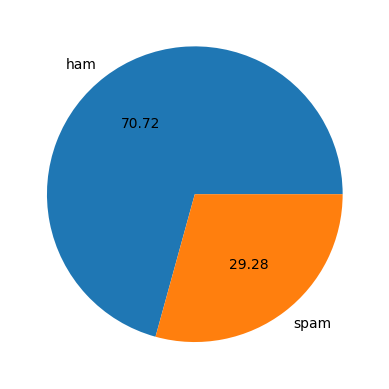

In [18]:
import matplotlib.pyplot as plt
plt.pie(df['Target'].value_counts(), labels = ['ham', 'spam'], autopct = '%0.2f')
plt.show()

# Data is Imbalanced

In [19]:
import nltk

In [20]:
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to C:\Users\M.Hashir
[nltk_data]     Abdullah/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\M.Hashir
[nltk_data]     Abdullah/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
df['num_char'] =df['Text'].apply(len)

In [22]:
df.head()

,Target,Text,num_char
0,0,Subject: enron methanol ; meter # : 988291\r\n...,327
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",97
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",2524
3,1,"Subject: photoshop , windows , office . cheap ...",414
4,0,Subject: re : indian springs\r\nthis deal is t...,336


In [23]:
from nltk.tokenize import word_tokenize
# Convert lists to strings and tokenize
df['Text'] = df['Text'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)  # Join list elements into a string
df['num_words'] = df['Text'].apply(lambda x:len (word_tokenize(x)))

In [24]:
print(df['num_words'])

0        68
1        24
2       551
3        49
4        71
       ... 
5165    197
5166    156
5167    306
5169    112
5170    200
Name: num_words, Length: 4993, dtype: int64


In [25]:
df.head()

,Target,Text,num_char,num_words
0,0,Subject: enron methanol ; meter # : 988291\r\n...,327,68
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",97,24
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",2524,551
3,1,"Subject: photoshop , windows , office . cheap ...",414,49
4,0,Subject: re : indian springs\r\nthis deal is t...,336,71


In [26]:
from nltk.tokenize import sent_tokenize
df['num_sentences'] = df['Text'].apply(lambda x: len(sent_tokenize(x)))

In [27]:
df.head()

,Target,Text,num_char,num_words,num_sentences
0,0,Subject: enron methanol ; meter # : 988291\r\n...,327,68,3
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",97,24,3
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",2524,551,24
3,1,"Subject: photoshop , windows , office . cheap ...",414,49,3
4,0,Subject: re : indian springs\r\nthis deal is t...,336,71,3


In [28]:
df[['num_char', 'num_words', 'num_sentences']].describe()

,num_char,num_words,num_sentences
count,4993.000000,4993.000000,4993.000000
mean,1069.426397,233.678149,13.386942
std,1547.863387,340.702932,27.959959
min,11.000000,2.000000,1.000000
25%,256.000000,55.000000,4.000000
50%,557.000000,125.000000,7.000000
75%,1262.000000,288.000000,15.000000
max,32258.000000,8863.000000,1204.000000


In [29]:
# For Ham Messages
df[df['Target'] == 0][['num_char', 'num_words', 'num_sentences']].describe()

,num_char,num_words,num_sentences
count,3531.000000,3531.000000,3531.000000
mean,994.939394,230.516001,11.662419
std,1402.785831,337.018933,25.330035
min,18.000000,3.000000,1.000000
25%,241.000000,53.000000,4.000000
50%,538.000000,128.000000,7.000000
75%,1253.500000,298.500000,13.500000
max,32258.000000,8863.000000,1204.000000


In [30]:
# For Spam Messages
df[df['Target'] == 1][['num_char', 'num_words', 'num_sentences']].describe()

,num_char,num_words,num_sentences
count,1462.000000,1462.000000,1462.000000
mean,1249.326265,241.315321,17.551984
std,1840.112883,349.439381,33.111447
min,11.000000,2.000000,1.000000
25%,304.250000,60.000000,4.000000
50%,589.000000,119.500000,9.000000
75%,1305.000000,252.750000,19.000000
max,22073.000000,3963.000000,693.000000


In [31]:
import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

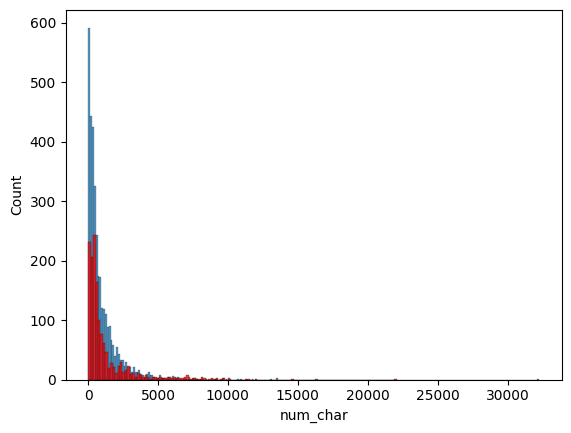

In [32]:
# Extract  messages form the data and then plot it
# 0 is Ham
# 1 is Spam
sns.histplot(df[df['Target'] == 0 ]['num_char'])
sns.histplot(df[df['Target'] == 1 ]['num_char'], color= 'red')

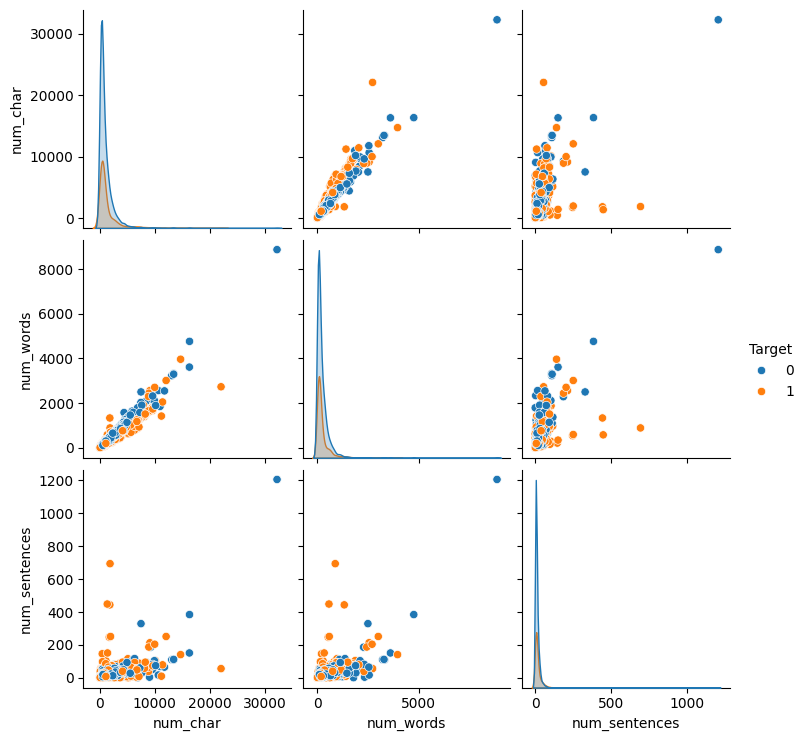

In [33]:
sns.pairplot(df, hue='Target')

## 3. DATA PRE-PROCESSING
- Lower case
- Tokenization
- Removing Special Characters
- Removing Stop words and punctuation
- Stemming


In [34]:
import nltk
import swifter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
import string

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')

# Initialize stemmer and stopwords
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)

def transform_text(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [ps.stem(word) for word in tokens if word.isalnum() and word not in stop_words and word not in punctuation]
    return " ".join(tokens)

# Apply the function efficiently
df['Transformed_text'] = df['Text'].swifter.apply(transform_text)

c:\Users\M.Hashir Abdullah\Desktop\web\DataMining\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to C:\Users\M.Hashir
[nltk_data]     Abdullah/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\M.Hashir
[nltk_data]     Abdullah/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Pandas Apply: 100%|██████████| 4993/4993 [00:58<00:00, 84.95it/s] 


In [35]:
df.head()

,Target,Text,num_char,num_words,num_sentences,Transformed_text
0,0,Subject: enron methanol ; meter # : 988291\r\n...,327,68,3,subject enron methanol meter 988291 follow not...
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",97,24,3,subject hpl nom januari 9 2001 see attach file...
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",2524,551,24,subject neon retreat ho ho ho around wonder ti...
3,1,"Subject: photoshop , windows , office . cheap ...",414,49,3,subject photoshop window offic cheap main tren...
4,0,Subject: re : indian springs\r\nthis deal is t...,336,71,3,subject indian spring deal book teco pvr reven...


In [36]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [37]:
# For Spam Messages
spam_wc = wc.generate(df[df['Target'] == 1]['Transformed_text'].str.cat(sep=' '))

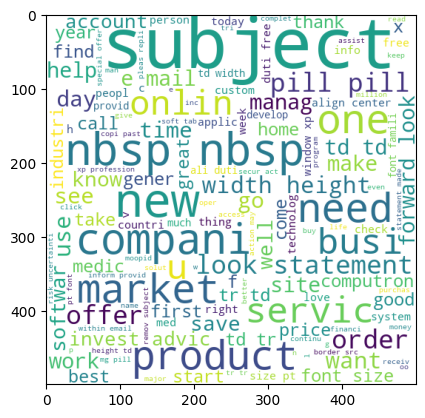

In [38]:
plt.imshow(spam_wc)

In [39]:
# For Ham Messages
ham_wc = wc.generate(df[df['Target'] == 0]['Transformed_text'].str.cat(sep=' '))

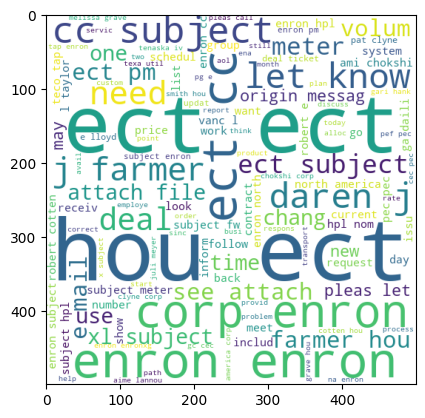

In [40]:
plt.imshow(ham_wc)

In [41]:
df.head()

,Target,Text,num_char,num_words,num_sentences,Transformed_text
0,0,Subject: enron methanol ; meter # : 988291\r\n...,327,68,3,subject enron methanol meter 988291 follow not...
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",97,24,3,subject hpl nom januari 9 2001 see attach file...
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",2524,551,24,subject neon retreat ho ho ho around wonder ti...
3,1,"Subject: photoshop , windows , office . cheap ...",414,49,3,subject photoshop window offic cheap main tren...
4,0,Subject: re : indian springs\r\nthis deal is t...,336,71,3,subject indian spring deal book teco pvr reven...


In [42]:
spam_corpus = []
for msg in df[df['Target'] == 1]['Transformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)
  # print(msg)
  # print('---')

In [43]:
len(spam_corpus)

196592

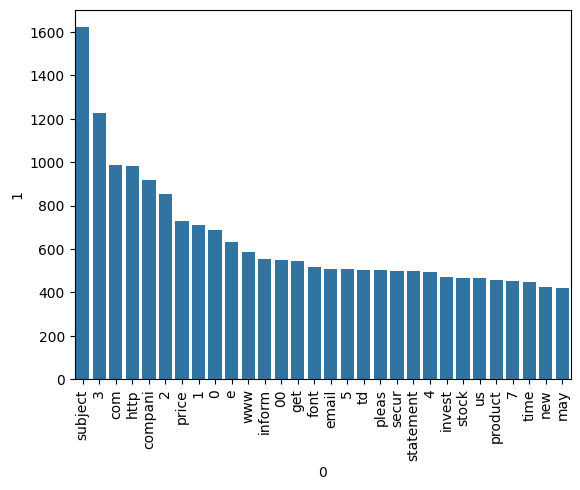

In [44]:
from collections import Counter
word_counts_df = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=word_counts_df[0], y=word_counts_df[1])
plt.xticks(rotation='vertical')
plt.show()

In [45]:
ham_corpus = []
for msg in df[df['Target'] == 0]['Transformed_text'].tolist():
    for word in msg.lower().split():
        ham_corpus.append(word)

In [46]:
len(ham_corpus)

380475

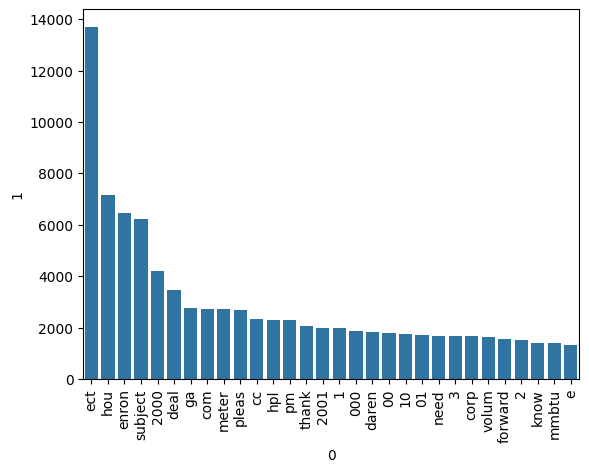

In [47]:
from collections import Counter
word_counts_df = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x=word_counts_df[0], y=word_counts_df[1])
plt.xticks(rotation='vertical')
plt.show()

In [48]:
df.head()

,Target,Text,num_char,num_words,num_sentences,Transformed_text
0,0,Subject: enron methanol ; meter # : 988291\r\n...,327,68,3,subject enron methanol meter 988291 follow not...
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",97,24,3,subject hpl nom januari 9 2001 see attach file...
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",2524,551,24,subject neon retreat ho ho ho around wonder ti...
3,1,"Subject: photoshop , windows , office . cheap ...",414,49,3,subject photoshop window offic cheap main tren...
4,0,Subject: re : indian springs\r\nthis deal is t...,336,71,3,subject indian spring deal book teco pvr reven...


## 4. Model Building

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [50]:
# Vectorize the text with limited features to avoid memory issues

tfidf = TfidfVectorizer(max_features=3000) # Limit to 3,000 features
X = tfidf.fit_transform(df['Transformed_text']).toarray()  # Dense for GaussianNB
print("Feature matrix shape:", X.shape)  # Check shape
y = df['Target'].values
print("Target shape:", y.shape)

Feature matrix shape: (4993, 3000)
Target shape: (4993,)


In [51]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (3994, 3000) (3994,)
Test set shape: (999, 3000) (999,)


In [52]:
# Initialize Classsification
# gnb = GaussianNB()
mnb = MultinomialNB()
# bnb = BernoulliNB()

In [53]:
# Train and evaluate Gaussian Naive Bayes
# gnb.fit(X_train, y_train)
# y_pred1 = gnb.predict(X_test)
# print("\n--- Gaussian Naive Bayes ---")
# print("Accuracy Score:", accuracy_score(y_test, y_pred1))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
# print("Precision Score:", precision_score(y_test, y_pred1))

In [54]:
# Train and evaluate Multinomial Naive Bayes
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print("\n--- Multinomial Naive Bayes ---")
print("Accuracy Score:", accuracy_score(y_test, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("Precision Score:", precision_score(y_test, y_pred2))


--- Multinomial Naive Bayes ---
Accuracy Score: 0.9329329329329329
Confusion Matrix:
 [[649  48]
 [ 19 283]]
Precision Score: 0.8549848942598187


In [55]:
# Train and evaluate Bernoulli Naive Bayes
# bnb.fit(X_train, y_train)
# y_pred3 = bnb.predict(X_test)
# print("\n--- Bernoulli Naive Bayes ---")
# print("Accuracy Score:", accuracy_score(y_test, y_pred3))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))
# print("Precision Score:", precision_score(y_test, y_pred3))

In [57]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))